In [2]:
import os
os.environ['KAGGLE_USERNAME'] = "key"
os.environ['KAGGLE_KEY'] = "token"

!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!unzip -q new-plant-diseases-dataset.zip -d dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:14<00:00, 197MB/s] 



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Đường dẫn dataset
train_dir = '/content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train'
valid_dir = '/content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.8, 1.2]
)

valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical'
)

NUM_CLASSES = train_generator.num_classes
print(f"Số class: {NUM_CLASSES}")

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Số class: 38


In [4]:
# Xây kiến trúc CNN cơ bản
model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2, 2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Flatten và Dense
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,254,438 (84.89 MB)

 Trainable params: 22,254,438 (84.89 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=valid_generator,
    verbose=1
)

print("Train xong!")

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1062s 480ms/step - accuracy: 0.4095 - loss: 2.0278 - val_accuracy: 0.6873 - val_loss: 0.9633
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1061s 483ms/step - accuracy: 0.6648 - loss: 1.0754 - val_accuracy: 0.8347 - val_loss: 0.5271
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1036s 471ms/step - accuracy: 0.7421 - loss: 0.8238 - val_accuracy: 0.8771 - val_loss: 0.3857
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1059s 482ms/step - accuracy: 0.7838 - loss: 0.6845 - val_accuracy: 0.8504 - val_loss: 0.4547
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1037s 472ms/step - accuracy: 0.8116 - loss: 0.6010 - val_accuracy: 0.9125 - val_loss: 0.2662
Epoch 6/10
  19/2197 ━━━━━━━━━━━━━━━━━━━━ 15:43 433ms/step - accuracy: 0.8314 - loss: 0.4744

KeyboardInterrupt: 

In [6]:
from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/plant_disease_dataset/baseline_cnn.keras')
print("Đã lưu model vào Drive!")

Mounted at /content/drive
Đã lưu model vào Drive!


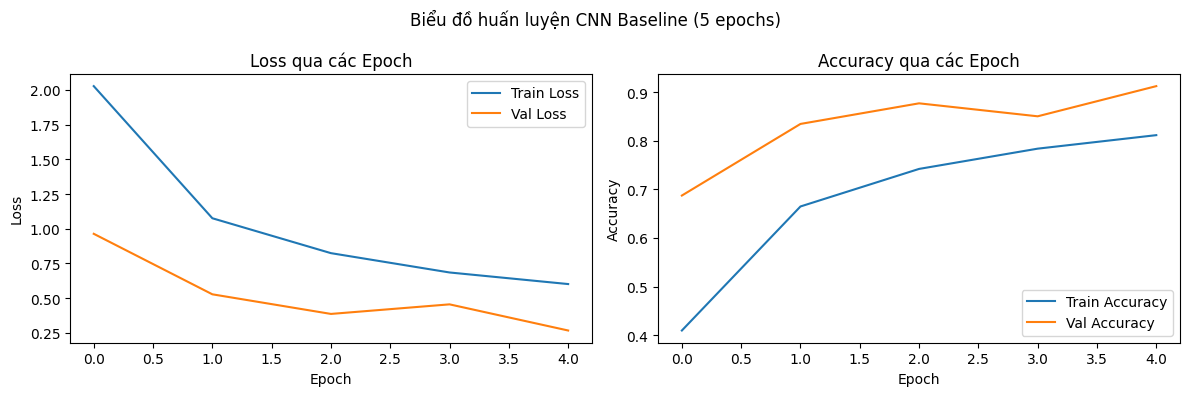

In [8]:
import matplotlib.pyplot as plt

# Số liệu từ log train
history_data = {
    'accuracy':     [0.4095, 0.6648, 0.7421, 0.7838, 0.8116],
    'val_accuracy': [0.6873, 0.8347, 0.8771, 0.8504, 0.9125],
    'loss':         [2.0278, 1.0754, 0.8238, 0.6845, 0.6010],
    'val_loss':     [0.9633, 0.5271, 0.3857, 0.4547, 0.2662]
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ Loss
axes[0].plot(history_data['loss'], label='Train Loss')
axes[0].plot(history_data['val_loss'], label='Val Loss')
axes[0].set_title('Loss qua các Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Biểu đồ Accuracy
axes[1].plot(history_data['accuracy'], label='Train Accuracy')
axes[1].plot(history_data['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy qua các Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Biểu đồ huấn luyện CNN Baseline (5 epochs)')
plt.tight_layout()
plt.savefig('training_history_cnn.png')
plt.show()